# Mumbai Local Train Deaths: A 10-Year Analysis (2015-2024)

Mumbai's suburban railway carries over 7.5 million commuters daily, and has one of
the highest fatality rates of any transit system in the world. This project analyzes
10 years of Government Railway Police (GRP) data to understand how death rates have
changed over time, what's driving them, and where the risk is concentrated.

**Data sources:** Compiled from GRP data as reported via RTI requests, covered by
Free Press Journal, The Indian Express, The Quint, and others (2018-2025).
See README for full source documentation and known limitations.

In [58]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('../data/mumbai_railway_deaths_2015_2024.csv')
print('Data loaded successfully!')
df.head()


Data loaded successfully!


,year,line_crossing,platform_gap_fall,fall_off_train,hit_railway_pole,others,total
0,2015,1801,40,806,13,644,3304
1,2016,1798,13,657,8,726,3202
2,2017,1651,18,654,12,679,3014
3,2018,1619,6,711,19,626,2981
4,2019,1455,4,611,9,612,2691


## Data overview
Quick check for data types, nulls, and summary statistics before analysis.

In [59]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   year               10 non-null     int64
 1   line_crossing      10 non-null     int64
 2   platform_gap_fall  10 non-null     int64
 3   fall_off_train     10 non-null     int64
 4   hit_railway_pole   10 non-null     int64
 5   others             10 non-null     int64
 6   total              10 non-null     int64
dtypes: int64(7)
memory usage: 692.0 bytes


,year,line_crossing,platform_gap_fall,fall_off_train,hit_railway_pole,others,total
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2019.50000,1371.400000,11.100000,575.300000,9.100000,595.600000,2562.500000
std,3.02765,351.561975,11.656662,196.977184,5.021067,174.613987,676.291234
min,2015.00000,730.000000,1.000000,177.000000,2.000000,206.000000,1116.000000
25%,2017.25000,1126.250000,3.250000,575.000000,6.000000,615.500000,2477.750000
50%,2019.50000,1366.000000,8.000000,632.500000,8.500000,659.000000,2640.500000
75%,2021.75000,1643.000000,13.750000,689.250000,12.000000,701.500000,3005.750000
max,2024.00000,1801.000000,40.000000,806.000000,19.000000,727.000000,3304.000000


## Overall trend: are deaths declining?

Total deaths per year, 2015-2024.

<Axes: xlabel='year', ylabel='total'>

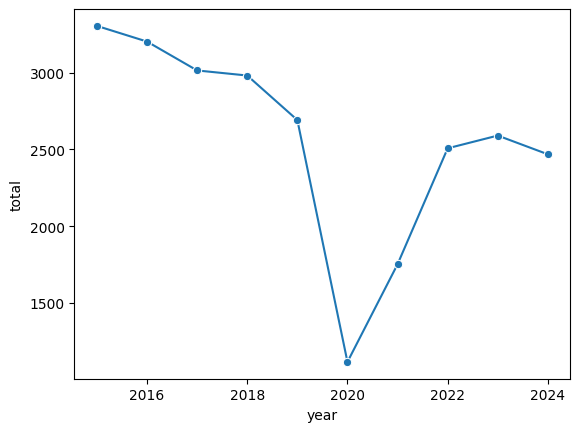

In [60]:
sns.lineplot(data=df, x='year', y='total', marker = 'o')

First thing I wanted to check: is this actually getting better over time? Mostly,
yes, deaths dropped from 3,304 in 2015 down to 2,691 in 2019, a fairly steady
decline. Then 2020 crashes down to 1,116, but that's not a safety story, that's
COVID shutting locals down to the general public. What caught my attention more
was after that: 2021 onward, numbers climb back up but settle around 2,500 a
year instead of continuing to fall like they were pre-2020. That plateau is the
thing I wanted to dig into more.

## What's driving the total?

Correlation between each cause of death and the yearly total.

<Axes: >

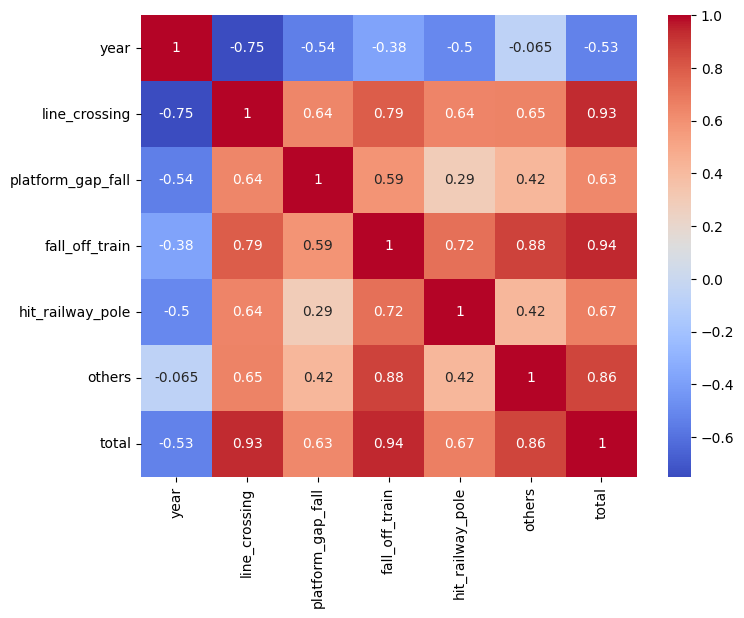

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

I expected track crossing to be the strongest driver of the yearly total, since
it's the biggest number every year by far. It's close, 0.93, but falling off
moving trains actually edges it out at 0.94. That surprised me a bit. Platform
gap falls barely move with the total at all (0.63), makes sense, it's a much
rarer, more random category. Worth keeping in mind though, with only 10 years
of data, I wouldn't read too much into a 0.01 gap between two variables, both
are clearly strong, the exact ranking is less important than that.

## The COVID structural break

A single regression line across 2015-2024 is misleading, it averages two genuinely
different periods. Splitting the trend at the 2020 disruption reveals what was
actually happening before and after.

Text(0, 0.5, 'Total deaths')

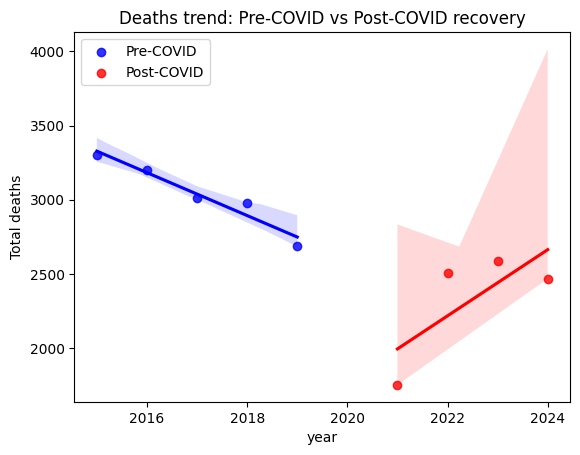

In [62]:

pre_covid = df[df['year'] <= 2019]
post_covid = df[df['year'] >= 2021]

sns.regplot(x='year', y='total', data=pre_covid, color='blue', label='Pre-COVID')
sns.regplot(x='year', y='total', data=post_covid, color='red', label='Post-COVID')
plt.legend()

plt.title('Deaths trend: Pre-COVID vs Post-COVID recovery')
plt.ylabel('Total deaths')


This is probably the most interesting thing I found in the whole project. If
you fit one straight line across 2015-2024, it looks like a steady decline, but
that's misleading, it's averaging two very different periods together. Splitting
it at the COVID break tells a different story: pre-COVID, the decline was real
and consistent, tight fit, high confidence. Post-COVID, that improvement hasn't
come back, the line's slope is actually pointing slightly upward now, though
with only 4 data points I'm not going to pretend that's a confident trend, the
confidence band on that red line is huge. What I can say is the plateau is real,
the improvement isn't.

## Central Railway vs Western Railway

Comparing death totals by line, 2022-2025 (limited data availability for earlier years).

<Axes: xlabel='year', ylabel='deaths'>

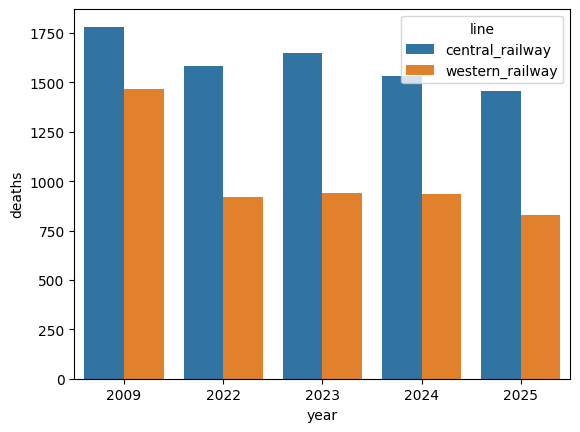

In [63]:
line_df = pd.read_csv('../data/mumbai_railway_deaths_by_line_fixed.csv')
line_df.head()


line_long = line_df.melt(id_vars=['year'], value_vars=['central_railway', 'western_railway'],
                          var_name='line', value_name='deaths')

sns.barplot(x='year', y='deaths', hue='line', data=line_long)

Central Railway has more deaths than Western Railway every single year, no
exceptions, so that part wasn't surprising. What I didn't expect was that the
gap seems to be growing, WR's numbers have come down more than CR's have over
the same stretch. I'd guess this comes down to where each line has actually
invested in things like foot overbridges or AC trains with auto-doors, but I
don't have that infrastructure data to confirm it, so this is more of a lead
for further digging than a conclusion. One thing worth flagging: the 2009
comparison point uses a different data source (railway operational data) than
2022-2025 (GRP data), so I'm not treating that specific jump as a clean
before-after number.

## Who is most at risk?

Deaths by cause and gender, 2024.

Text(0.5, 1.0, '2024: Deaths by cause and gender')

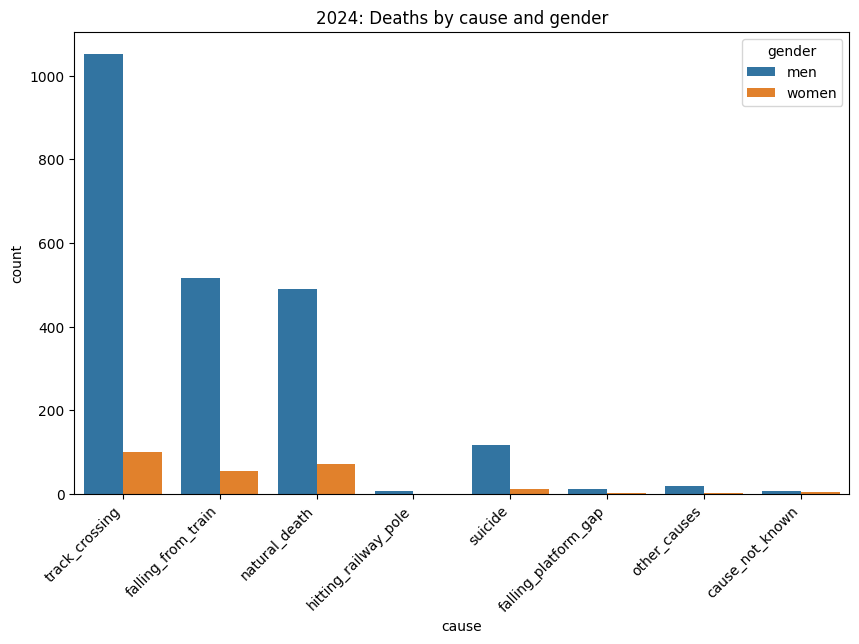

In [64]:
gender_df = pd.read_csv('../data/mumbai_railway_deaths_gender_split.csv')

gender_long = gender_df.melt(id_vars=['year','cause'], value_vars=['men','women'],
                              var_name='gender', value_name='count')

plt.figure(figsize=(10,6))
sns.barplot(x='cause', y='count', hue='gender', data=gender_long[gender_long['year']==2024])
plt.xticks(rotation=45, ha='right')
plt.title('2024: Deaths by cause and gender')

This one's stark. Men account for 85-95%+ of deaths in basically every cause
category I looked at, track crossing, falling off trains, suicide, doesn't
matter which one. That consistency across such different causes is what made
me think this isn't really about one specific risky behavior, it's something
broader. That said, I want to be careful here, I don't have ridership numbers
split by gender, so all I can actually say is that men make up most of the
victims in raw counts. I can't say men are more at risk per person riding,
that would need a denominator I don't have access to.

## Key takeaways

Going into this, I expected to find a simple downward trend, safety measures
working, deaths going down year over year. That's not quite what happened.

Deaths did decline steadily from 2015 to 2019, from 3,304 down to 2,691. But
2020's drop to 1,116 wasn't a safety win, it was COVID shutting down regular
train service. What's more interesting is what happened after: post-2021,
numbers settled around 2,500 a year and haven't gone back to improving at the
pre-COVID rate. Splitting the regression at the COVID break made this obvious,
one straight line across all 10 years would have hidden it completely.

A few other things stood out:

- Falling off moving trains actually correlates more strongly with the yearly
  total (0.94) than track crossing does (0.93), even though crossing has the
  higher raw numbers every single year
- Central Railway consistently has more deaths than Western Railway, and that
  gap has been widening, WR seems to be improving faster
- Men make up 85-95% of deaths across almost every cause, not just one category,
  which suggests this isn't specific to one type of risky behavior

## Limitations

I want to be upfront about where this analysis is weaker than I'd like:

- 10 years of data isn't a lot to build confident regression lines on, especially
  the post-COVID split, which only has 4 points. The direction of that trend line
  could shift a lot with just one or two more years of data
- GRP data and Railway operational data count different things (GRP includes
  natural deaths and suicides, Railway data doesn't), so numbers from different
  years aren't always a clean apples-to-apples comparison
- I don't have ridership numbers broken down by gender, so I can only say men
  account for most deaths in raw counts, not that men face higher risk per
  person riding
- Anything before 2015 only exists as multi-year totals in the sources I found,
  not full cause breakdowns, so I couldn't extend this further back cleanly